# IoT Room Occupancy Estimation: Sensor Analytics & Data Engineering

An exploratory data analysis and sensor analytics project exploring environmental telemetry across **10,129 multi-sensor observations** to estimate room occupancy levels.

---

- **Author:** alperencok


## 1. Environment Setup & Library Imports
Configuring standard numerical processing and visualization libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font="sans-serif")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial"]

## 2. Dataset Ingestion (Question 1)
Loading the raw multi-sensor telemetry dataset `Occupancy_Estimation_1_new.csv`.

In [2]:
csv_path = "data/Occupancy_Estimation_Raw.csv" if os.path.exists("data/Occupancy_Estimation_Raw.csv") else "Occupancy_Estimation_1_new.csv"
df = pd.read_csv(csv_path)

print(f"Dataset successfully loaded: {df.shape[0]:,} observations across {df.shape[1]} features.")
df.info()

Dataset successfully loaded: 10,129 observations across 19 features.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10129 entries, 0 to 10128
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  10129 non-null  object 
 1   Time                  10129 non-null  object 
 2   S1_Temp               6911 non-null   float64
 3   S2_Temp               877 non-null    float64
 4   S3_Temp               3457 non-null   float64
 5   S4_Temp               6729 non-null   float64
 6   S1_Light              480 non-null    float64
 7   S2_Light              8845 non-null   float64
 8   S3_Light              10129 non-null  int64  
 9   S4_Light              5368 non-null   float64
 10  S1_Sound              6259 non-null   float64
 11  S2_Sound              6344 non-null   float64
 12  S3_Sound              6165 non-null   float64
 13  S4_Sound              9712 non-null   float64
 14  S

## 3. Exploratory Row Inspection (Question 2)
Displaying the first 8, 12, and 25 rows separately to inspect recording intervals and sensor scales.

In [3]:
# Display first 8 rows
df.head(8)

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,2017/12/22,10:49:41,24.94,NaN,NaN,NaN,NaN,34.0,53,40.0,0.08,NaN,0.06,0.06,NaN,0.769231,0.0,NaN,NaN
1,2017/12/22,10:50:12,24.94,NaN,NaN,25.44,NaN,33.0,53,40.0,NaN,0.05,NaN,0.06,390.0,NaN,0.0,0.0,1.0
2,2017/12/22,10:50:42,25.00,NaN,NaN,25.44,NaN,34.0,53,NaN,NaN,0.11,0.08,0.06,390.0,0.519231,0.0,NaN,NaN
3,2017/12/22,10:51:13,25.00,24.75,NaN,25.44,NaN,34.0,53,40.0,NaN,0.10,0.10,0.09,390.0,0.388462,0.0,NaN,1.0
4,2017/12/22,10:51:44,25.00,NaN,24.56,NaN,NaN,34.0,54,NaN,0.18,0.06,0.06,NaN,390.0,NaN,0.0,NaN,NaN
5,2017/12/22,10:52:14,NaN,NaN,NaN,25.44,NaN,34.0,54,40.0,0.13,0.06,NaN,0.07,390.0,0.165385,0.0,NaN,NaN
6,2017/12/22,10:52:45,25.00,NaN,NaN,NaN,NaN,34.0,54,NaN,1.39,0.32,0.43,0.06,390.0,0.076923,1.0,0.0,1.0
7,2017/12/22,10:53:15,25.00,NaN,24.56,NaN,NaN,34.0,54,41.0,NaN,NaN,NaN,0.05,390.0,-0.011538,0.0,0.0,1.0


In [4]:
# Display first 12 rows
df.head(12)

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,2017/12/22,10:49:41,24.94,NaN,NaN,NaN,NaN,34.0,53,40.0,0.08,NaN,0.06,0.06,NaN,0.769231,0.0,NaN,NaN
1,2017/12/22,10:50:12,24.94,NaN,NaN,25.44,NaN,33.0,53,40.0,NaN,0.05,NaN,0.06,390.0,NaN,0.0,0.0,1.0
2,2017/12/22,10:50:42,25.00,NaN,NaN,25.44,NaN,34.0,53,NaN,NaN,0.11,0.08,0.06,390.0,0.519231,0.0,NaN,NaN
3,2017/12/22,10:51:13,25.00,24.75,NaN,25.44,NaN,34.0,53,40.0,NaN,0.10,0.10,0.09,390.0,0.388462,0.0,NaN,1.0
4,2017/12/22,10:51:44,25.00,NaN,24.56,NaN,NaN,34.0,54,NaN,0.18,0.06,0.06,NaN,390.0,NaN,0.0,NaN,NaN
5,2017/12/22,10:52:14,NaN,NaN,NaN,25.44,NaN,34.0,54,40.0,0.13,0.06,NaN,0.07,390.0,0.165385,0.0,NaN,NaN
6,2017/12/22,10:52:45,25.00,NaN,NaN,NaN,NaN,34.0,54,NaN,1.39,0.32,0.43,0.06,390.0,0.076923,1.0,0.0,1.0
7,2017/12/22,10:53:15,25.00,NaN,24.56,NaN,NaN,34.0,54,41.0,NaN,NaN,NaN,0.05,390.0,-0.011538,0.0,0.0,1.0
8,2017/12/22,10:53:46,25.00,NaN,24.56,NaN,NaN,35.0,56,NaN,NaN,NaN,NaN,0.13,390.0,-0.100000,0.0,NaN,NaN
9,2017/12/22,10:54:17,NaN,NaN,24.56,NaN,NaN,34.0,57,NaN,NaN,NaN,0.48,0.39,390.0,-0.188462,1.0,NaN,NaN


In [5]:
# Display first 25 rows
df.head(25)

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,2017/12/22,10:49:41,24.94,NaN,NaN,NaN,NaN,34.0,53,40.0,0.08,NaN,0.06,0.06,NaN,0.769231,0.0,NaN,NaN
1,2017/12/22,10:50:12,24.94,NaN,NaN,25.44,NaN,33.0,53,40.0,NaN,0.05,NaN,0.06,390.0,NaN,0.0,0.0,1.0
2,2017/12/22,10:50:42,25.00,NaN,NaN,25.44,NaN,34.0,53,NaN,NaN,0.11,0.08,0.06,390.0,0.519231,0.0,NaN,NaN
3,2017/12/22,10:51:13,25.00,24.75,NaN,25.44,NaN,34.0,53,40.0,NaN,0.10,0.10,0.09,390.0,0.388462,0.0,NaN,1.0
4,2017/12/22,10:51:44,25.00,NaN,24.56,NaN,NaN,34.0,54,NaN,0.18,0.06,0.06,NaN,390.0,NaN,0.0,NaN,NaN
5,2017/12/22,10:52:14,NaN,NaN,NaN,25.44,NaN,34.0,54,40.0,0.13,0.06,NaN,0.07,390.0,0.165385,0.0,NaN,NaN
6,2017/12/22,10:52:45,25.00,NaN,NaN,NaN,NaN,34.0,54,NaN,1.39,0.32,0.43,0.06,390.0,0.076923,1.0,0.0,1.0
7,2017/12/22,10:53:15,25.00,NaN,24.56,NaN,NaN,34.0,54,41.0,NaN,NaN,NaN,0.05,390.0,-0.011538,0.0,0.0,1.0
8,2017/12/22,10:53:46,25.00,NaN,24.56,NaN,NaN,35.0,56,NaN,NaN,NaN,NaN,0.13,390.0,-0.100000,0.0,NaN,NaN
9,2017/12/22,10:54:17,NaN,NaN,24.56,NaN,NaN,34.0,57,NaN,NaN,NaN,0.48,0.39,390.0,-0.188462,1.0,NaN,NaN


## 4. Schema & Data Type Verification (Questions 3, 4, 5)
Inspecting single-row type slices, column-wide data types, and attribute names.

In [6]:
# Question 3: Check data types of at least 5 rows separately
for i in range(5):
    print(f"--- Row Slice [{i}:{i+1}] Dtypes ---")
    print(df[i:i+1].dtypes)
    print()

--- Row Slice [0:1] Dtypes ---
Date                     object
Time                     object
S1_Temp                 float64
S2_Temp                 float64
S3_Temp                 float64
S4_Temp                 float64
S1_Light                float64
S2_Light                float64
S3_Light                  int64
S4_Light                float64
S1_Sound                float64
S2_Sound                float64
S3_Sound                float64
S4_Sound                float64
S5_CO2                  float64
S5_CO2_Slope            float64
S6_PIR                  float64
S7_PIR                  float64
Room_Occupancy_Count    float64
dtype: object

--- Row Slice [1:2] Dtypes ---
Date                     object
Time                     object
S1_Temp                 float64
S2_Temp                 float64
S3_Temp                 float64
S4_Temp                 float64
S1_Light                float64
S2_Light                float64
S3_Light                  int64
S4_Light                flo

In [7]:
# Question 4: Check data types across all columns
print("--- Full Dataset Column Dtypes ---")
print(df.dtypes)

--- Full Dataset Column Dtypes ---
Date                     object
Time                     object
S1_Temp                 float64
S2_Temp                 float64
S3_Temp                 float64
S4_Temp                 float64
S1_Light                float64
S2_Light                float64
S3_Light                  int64
S4_Light                float64
S1_Sound                float64
S2_Sound                float64
S3_Sound                float64
S4_Sound                float64
S5_CO2                  float64
S5_CO2_Slope            float64
S6_PIR                  float64
S7_PIR                  float64
Room_Occupancy_Count    float64
dtype: object


In [8]:
# Question 5: List column names of the DataFrame
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Date', 'Time', 'S1_Temp', 'S2_Temp', 'S3_Temp', 'S4_Temp', 'S1_Light', 'S2_Light', 'S3_Light', 'S4_Light', 'S1_Sound', 'S2_Sound', 'S3_Sound', 'S4_Sound', 'S5_CO2', 'S5_CO2_Slope', 'S6_PIR', 'S7_PIR', 'Room_Occupancy_Count']


## 5. Type Transformation & Non-Numeric Column Extraction (Questions 6, 7)
Copying DataFrame, casting between integer and float representations, and isolating non-numeric attributes.

In [9]:
# Question 6: Copy DataFrame and cast data types
copydf = df.copy()

# 6a. Convert integer column to float
copydf["S3_Light"] = copydf["S3_Light"].astype(float)
print(f"S3_Light dtype after float casting: {copydf['S3_Light'].dtype}")

# 6b. Convert float column to integer (using nullable Int64 to handle missing values)
copydf["S1_Temp_Int"] = copydf["S1_Temp"].round().astype("Int64")
print("S1_Temp_Int sample values:")
print(copydf["S1_Temp_Int"].dropna().head(5))

S3_Light dtype after float casting: float64
S1_Temp_Int sample values:
0    25
1    25
2    25
3    25
4    25
Name: S1_Temp_Int, dtype: Int64


In [10]:
# Question 7: Extract non-numeric columns into a dedicated DataFrame
non_numeric_df = df.select_dtypes(exclude=["number"])
print(f"Non-numeric DataFrame shape: {non_numeric_df.shape}")
non_numeric_df.head()

Non-numeric DataFrame shape: (10129, 2)


,Date,Time
0,2017/12/22,10:49:41
1,2017/12/22,10:50:12
2,2017/12/22,10:50:42
3,2017/12/22,10:51:13
4,2017/12/22,10:51:44


## 6. Relational Querying & Conditional Filtering (Questions 8, 12)
Filtering observations utilizing relational operators (`<`, `<=`, `>`, `>=`, `==`) and custom compound masks.

In [11]:
# Question 8a: Date equality filter (==)
filter_date = df[df["Date"] == "2017/12/23"]
print(f"Records on 2017/12/23: {len(filter_date)}")

# Question 8b: S1 Temperature below 25°C (<)
filter_temp_low = df[df["S1_Temp"] < 25]
print(f"Records with S1_Temp < 25°C: {len(filter_temp_low)}")

# Question 8c: S2 Temperature at or above 25°C (>=)
filter_temp_high = df[df["S2_Temp"] >= 25]
print(f"Records with S2_Temp >= 25°C: {len(filter_temp_high)}")

# Question 8d: S3 Light equal to median value (==)
s3_median = df["S3_Light"].median()
filter_light_med = df[df["S3_Light"] == s3_median]
print(f"Records with S3_Light == median ({s3_median}): {len(filter_light_med)}")

# Question 8e: S5 CO2 slope negative (< 0)
filter_co2_decline = df[df["S5_CO2_Slope"] < 0]
print(f"Records with negative CO2 slope: {len(filter_co2_decline)}")

Records on 2017/12/23: 2779
Records with S1_Temp < 25°C: 2
Records with S2_Temp >= 25°C: 872
Records with S3_Light == median (0.0): 5591
Records with negative CO2 slope: 2729


In [12]:
# Question 12: Custom compound filter based on domain criteria
# Specific observation date with elevated ambient CO2 (> 400 ppm)
custom_filter = (df["Date"] == "2018/01/10") & (df["S5_CO2"] > 400)
custom_subset = df[custom_filter]
print(f"Observations matching compound filter: {len(custom_subset)}")
custom_subset[["Date", "Time", "S1_Temp", "S5_CO2", "Room_Occupancy_Count"]].head(8)

Observations matching compound filter: 499


,Date,Time,S1_Temp,S5_CO2,Room_Occupancy_Count
8135,2018/01/10,15:51:50,NaN,405.0,3.0
8136,2018/01/10,15:52:21,25.69,420.0,NaN
8137,2018/01/10,15:52:52,25.69,430.0,NaN
8138,2018/01/10,15:53:22,NaN,425.0,NaN
8139,2018/01/10,15:53:53,NaN,425.0,3.0
8140,2018/01/10,15:54:23,NaN,420.0,3.0
8141,2018/01/10,15:54:54,NaN,420.0,3.0
8142,2018/01/10,15:55:25,25.69,425.0,NaN


## 7. Dimensional Slicing & Positional Indexing (Questions 10, 11, 13, 14)
Demonstrating both index-based positional indexing (`.iloc`) and label-based indexing (`.loc`).

In [13]:
# Question 10: Display range of rows (1-5) and 1st, 2nd, 4th, 6th columns
df.iloc[0:5, [0, 1, 3, 5]]

,Date,Time,S2_Temp,S4_Temp
0,2017/12/22,10:49:41,NaN,NaN
1,2017/12/22,10:50:12,NaN,25.44
2,2017/12/22,10:50:42,NaN,25.44
3,2017/12/22,10:51:13,24.75,25.44
4,2017/12/22,10:51:44,NaN,NaN


In [14]:
# Question 11: Display 3rd through 10th rows and the first four columns
df.iloc[2:10, 0:4]

,Date,Time,S1_Temp,S2_Temp
2,2017/12/22,10:50:42,25.0,NaN
3,2017/12/22,10:51:13,25.0,24.75
4,2017/12/22,10:51:44,25.0,NaN
5,2017/12/22,10:52:14,NaN,NaN
6,2017/12/22,10:52:45,25.0,NaN
7,2017/12/22,10:53:15,25.0,NaN
8,2017/12/22,10:53:46,25.0,NaN
9,2017/12/22,10:54:17,NaN,NaN


In [15]:
# Question 13: Slicing using label/index range and explicit column names (.loc)
df.loc[53:58, ["Date", "Time", "S5_CO2"]]

,Date,Time,S5_CO2
53,2017/12/22,11:16:45,420.0
54,2017/12/22,11:17:15,430.0
55,2017/12/22,11:17:46,435.0
56,2017/12/22,11:18:17,430.0
57,2017/12/22,11:18:47,445.0
58,2017/12/22,11:19:18,440.0


In [16]:
# Question 14: Slicing using purely integer indices (.iloc)
df.iloc[53:58, [0, 1, 14]]

,Date,Time,S5_CO2
53,2017/12/22,11:16:45,420.0
54,2017/12/22,11:17:15,430.0
55,2017/12/22,11:17:46,435.0
56,2017/12/22,11:18:17,430.0
57,2017/12/22,11:18:47,445.0


## 8. Grouping & Multi-Metric Aggregations (Question 9)
Performing grouped aggregations across environmental dimensions:
1. **Average S1 Temperature** grouped by `Room_Occupancy_Count`
2. **Median S5 CO2 Slope** grouped by `Date`
3. **Cumulative Room Occupancy Count** grouped by `Date`
4. **Minimum & Maximum S5 CO2 Concentrations** grouped by `Room_Occupancy_Count`

In [17]:
# Aggregation 1: Mean temperature by occupancy count
print("1. Mean S1_Temp by Room_Occupancy_Count:")
print(df.groupby("Room_Occupancy_Count")["S1_Temp"].mean().round(3))

1. Mean S1_Temp by Room_Occupancy_Count:
Room_Occupancy_Count
0.0    25.332
1.0    25.769
2.0    26.012
3.0    26.070
Name: S1_Temp, dtype: float64


In [18]:
# Aggregation 2: Median CO2 slope by date
print("2. Median S5_CO2_Slope by Date:")
print(df.groupby("Date")["S5_CO2_Slope"].median().round(4).head(8))

2. Median S5_CO2_Slope by Date:
Date
2017/12/22    0.2538
2017/12/23    0.0000
2017/12/24    0.0000
2017/12/25    0.0000
2017/12/26    0.0000
2018/01/10   -0.0846
2018/01/11    0.0000
Name: S5_CO2_Slope, dtype: float64


In [19]:
# Aggregation 3: Total occupancy sum by date
print("3. Cumulative Room_Occupancy_Count by Date:")
print(df.groupby("Date")["Room_Occupancy_Count"].sum())

3. Cumulative Room_Occupancy_Count by Date:
Date
2017/12/22    845.0
2017/12/23    612.0
2017/12/24      0.0
2017/12/25      0.0
2017/12/26      0.0
2018/01/10    367.0
2018/01/11      0.0
Name: Room_Occupancy_Count, dtype: float64


In [20]:
# Aggregation 4: Minimum and Maximum CO2 levels by occupancy
print("4. Min & Max S5_CO2 by Room_Occupancy_Count:")
co2_extrema = df.groupby("Room_Occupancy_Count")["S5_CO2"].agg(["min", "max", "mean"]).round(1)
print(co2_extrema)

4. Min & Max S5_CO2 by Room_Occupancy_Count:
                        min     max   mean
Room_Occupancy_Count                      
0.0                   345.0  1250.0  402.1
1.0                   360.0   630.0  471.1
2.0                   380.0  1065.0  715.0
3.0                   370.0  1270.0  847.8


## 9. Missing Value Diagnostics & Imputation Benchmarking (Questions 15, 16, 17, 18)
Evaluating missing value density and comparing 4 imputation approaches:
- **Strategy A:** Column Mean Imputation
- **Strategy B:** Column Minimum Imputation
- **Strategy C:** Column Maximum Imputation
- **Strategy D (Final):** Zero-fill Imputation (`df_zero`) for baseline modeling and export.

In [21]:
# Question 15: Check null values per column
print("--- Missing Values Per Column ---")
print(df.isnull().sum())

--- Missing Values Per Column ---
Date                       0
Time                       0
S1_Temp                 3218
S2_Temp                 9252
S3_Temp                 6672
S4_Temp                 3400
S1_Light                9649
S2_Light                1284
S3_Light                   0
S4_Light                4761
S1_Sound                3870
S2_Sound                3785
S3_Sound                3964
S4_Sound                 417
S5_CO2                    74
S5_CO2_Slope            1287
S6_PIR                  1268
S7_PIR                  8196
Room_Occupancy_Count    5675
dtype: int64


In [22]:
# Question 16: Total missing values across the entire DataFrame
total_missing = df.isnull().sum().sum()
print(f"Total Missing Values in Dataset: {total_missing:,}")

Total Missing Values in Dataset: 66,772


In [23]:
# Question 17: Imputation strategies
# 17a. Impute with Mean
df_mean = df.copy()
numeric_cols = df_mean.select_dtypes(include="number").columns
for c in numeric_cols:
    df_mean[c] = df_mean[c].fillna(df_mean[c].mean())

# 17b. Impute with Minimum
df_min = df.copy()
for c in numeric_cols:
    df_min[c] = df_min[c].fillna(df_min[c].min())

# 17c. Impute with Maximum
df_max = df.copy()
for c in numeric_cols:
    df_max[c] = df_max[c].fillna(df_max[c].max())

# Final Strategy: Zero Fill (for deterministic baseline)
df_zero = df.copy()
for c in numeric_cols:
    df_zero[c] = df_zero[c].fillna(0)

print(f"Remaining nulls after zero imputation: {df_zero.isnull().sum().sum()}")

Remaining nulls after zero imputation: 0


In [24]:
# Question 18: Export cleaned dataset to CSV
output_csv = "Occupancy_Estimation_Cleaned.csv"
df_zero.to_csv(output_csv, index=False)
print(f"Cleaned dataset successfully exported to: {output_csv}")

Cleaned dataset successfully exported to: Occupancy_Estimation_Cleaned.csv


## 10. Exploratory Visualization Suite & Sensor Diagnostics (Question 19)
Rendering 7 distinct diagnostic charts exploring telemetry distributions, occupancy proportions, and correlation dynamics.

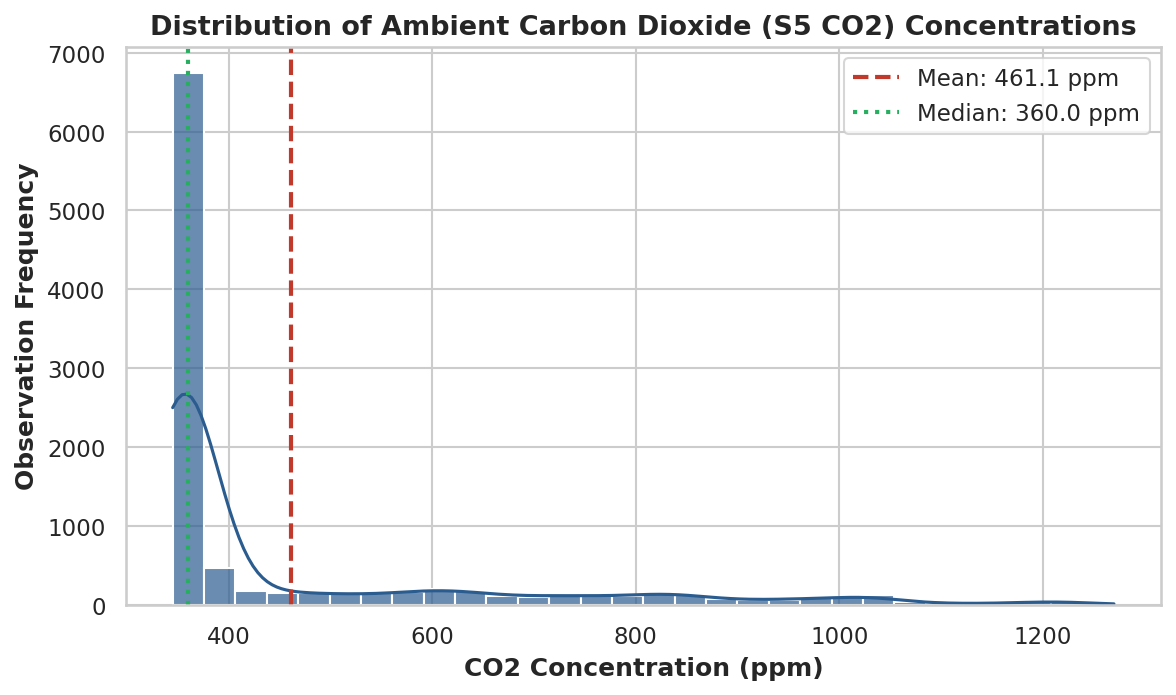

In [25]:
# Figure 1: Histogram of Carbon Dioxide (S5 CO2)
fig, ax = plt.subplots(figsize=(8, 4.8))
co2_data = df_zero[df_zero["S5_CO2"] > 0]["S5_CO2"]
sns.histplot(co2_data, bins=30, kde=True, color="#2b5c8f", ax=ax, edgecolor="white", alpha=0.7)
ax.axvline(co2_data.mean(), color="#c0392b", linestyle="--", linewidth=2, label=f"Mean: {co2_data.mean():.1f} ppm")
ax.axvline(co2_data.median(), color="#27ae60", linestyle=":", linewidth=2, label=f"Median: {co2_data.median():.1f} ppm")

ax.set_title("Distribution of Ambient Carbon Dioxide (S5 CO2) Concentrations", fontsize=13, fontweight="bold")
ax.set_xlabel("CO2 Concentration (ppm)", fontweight="bold")
ax.set_ylabel("Observation Frequency", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

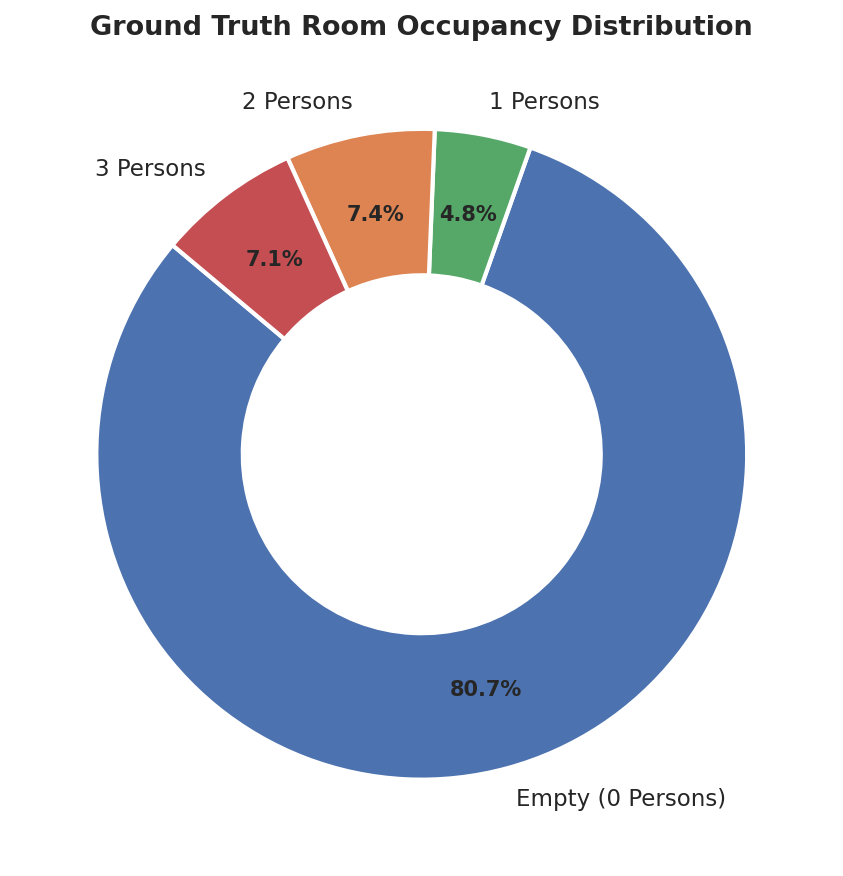

In [26]:
# Figure 2: Pie / Donut Chart of Room Occupancy Distribution
fig, ax = plt.subplots(figsize=(6.5, 6))
valid_occ = df.dropna(subset=["Room_Occupancy_Count"])
counts = valid_occ["Room_Occupancy_Count"].value_counts().sort_index()
labels = [f"{int(k)} Persons" if k > 0 else "Empty (0 Persons)" for k in counts.index]
colors = ["#4C72B0", "#55A868", "#DD8452", "#C44E52"]

wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    pctdistance=0.75,
    wedgeprops=dict(width=0.45, edgecolor="white", linewidth=2)
)
for t in autotexts:
    t.set_fontsize(10)
    t.set_fontweight("bold")

ax.set_title("Ground Truth Room Occupancy Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

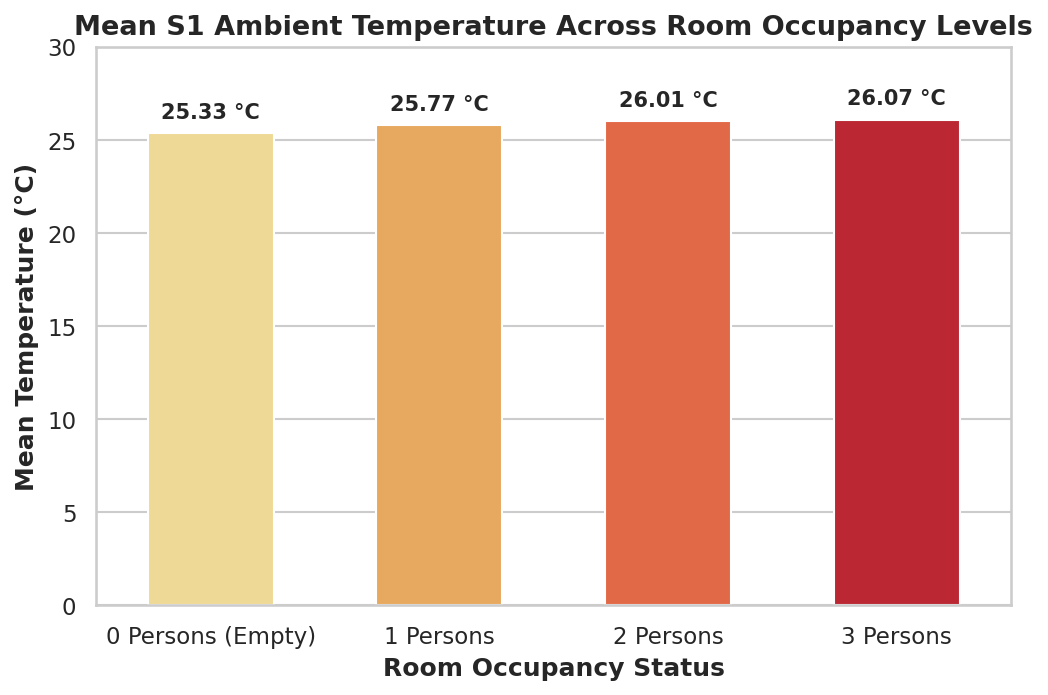

In [27]:
# Figure 3: Mean S1 Ambient Temperature by Room Occupancy Level
fig, ax = plt.subplots(figsize=(7, 4.8))
temp_occ = valid_occ.dropna(subset=["S1_Temp"]).groupby("Room_Occupancy_Count")["S1_Temp"].mean().reset_index()
temp_occ["occupancy_label"] = [f"{int(c)} Persons" if c > 0 else "0 Persons (Empty)" for c in temp_occ["Room_Occupancy_Count"]]

bars = sns.barplot(data=temp_occ, x="occupancy_label", y="S1_Temp", hue="occupancy_label", palette="YlOrRd", ax=ax, width=0.55, legend=False)
ax.set_title("Mean S1 Ambient Temperature Across Room Occupancy Levels", fontsize=13, fontweight="bold")
ax.set_xlabel("Room Occupancy Status", fontweight="bold")
ax.set_ylabel("Mean Temperature (°C)", fontweight="bold")
ax.set_ylim(0, 30)

for b in bars.patches:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h + 0.6, f"{h:.2f} °C", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

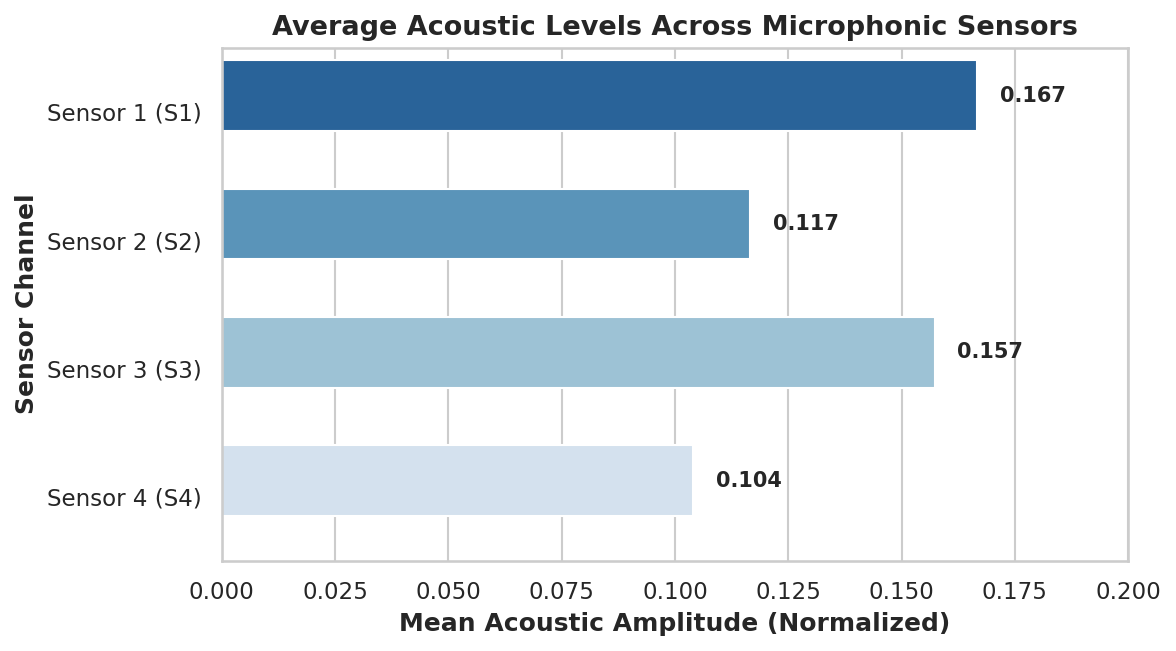

In [28]:
# Figure 4: Horizontal Bar Chart of Sound Sensor Averages
fig, ax = plt.subplots(figsize=(8, 4.5))
sound_cols = ["S1_Sound", "S2_Sound", "S3_Sound", "S4_Sound"]
sound_means = df[sound_cols].mean()
sound_df = pd.DataFrame({
    "sensor": ["Sensor 1 (S1)", "Sensor 2 (S2)", "Sensor 3 (S3)", "Sensor 4 (S4)"],
    "mean_sound": sound_means.values
})

bars = sns.barplot(data=sound_df, x="mean_sound", y="sensor", hue="sensor", palette="Blues_r", ax=ax, height=0.55, legend=False)
ax.set_title("Average Acoustic Levels Across Microphonic Sensors", fontsize=13, fontweight="bold")
ax.set_xlabel("Mean Acoustic Amplitude (Normalized)", fontweight="bold")
ax.set_ylabel("Sensor Channel", fontweight="bold")

for b in bars.patches:
    w = b.get_width()
    ax.text(w + 0.005, b.get_y() + b.get_height()/2, f"{w:.3f}", va="center", ha="left", fontsize=10, fontweight="bold")

ax.set_xlim(0, max(sound_means.values) * 1.2)
plt.tight_layout()
plt.show()

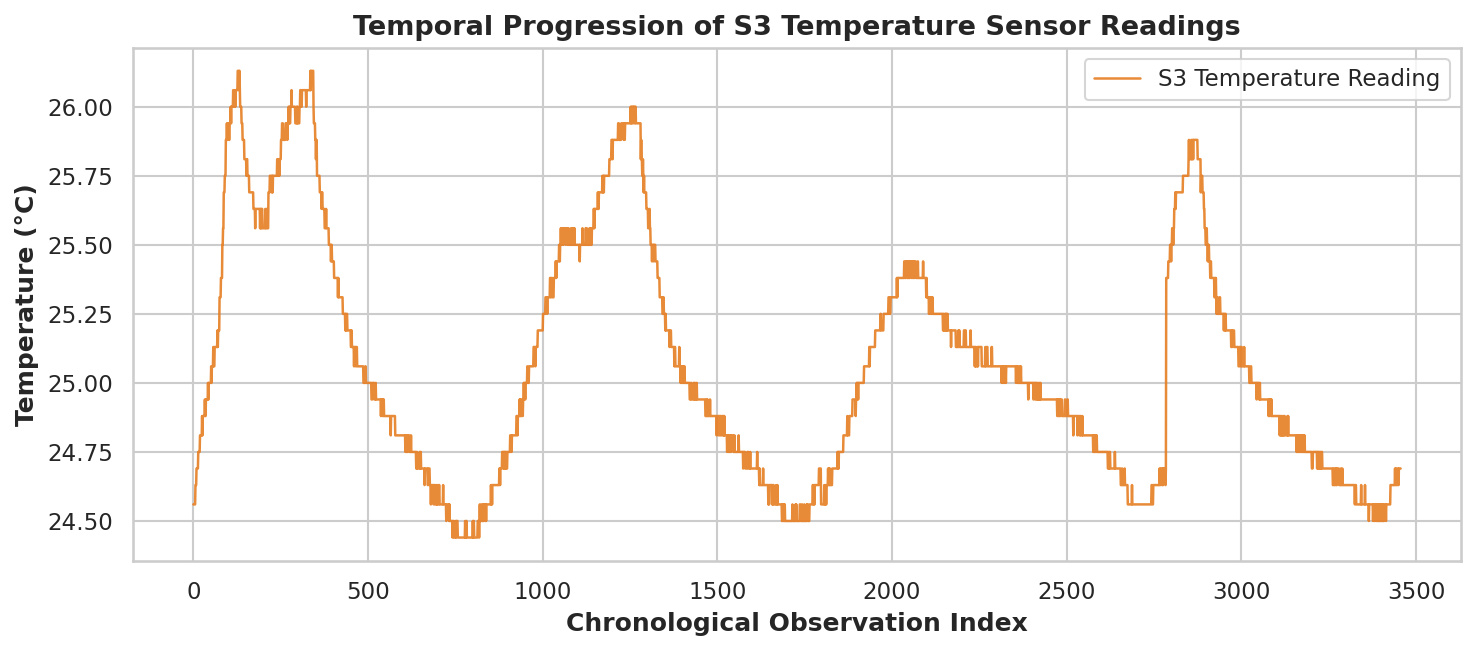

In [29]:
# Figure 5: Line Graph of S3 Temperature Progression
fig, ax = plt.subplots(figsize=(10, 4.5))
s3_vals = df["S3_Temp"].dropna().reset_index(drop=True)
ax.plot(s3_vals.index, s3_vals.values, color="#e67e22", linewidth=1.2, alpha=0.9, label="S3 Temperature Reading")
ax.set_title("Temporal Progression of S3 Temperature Sensor Readings", fontsize=13, fontweight="bold")
ax.set_xlabel("Chronological Observation Index", fontweight="bold")
ax.set_ylabel("Temperature (°C)", fontweight="bold")
ax.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

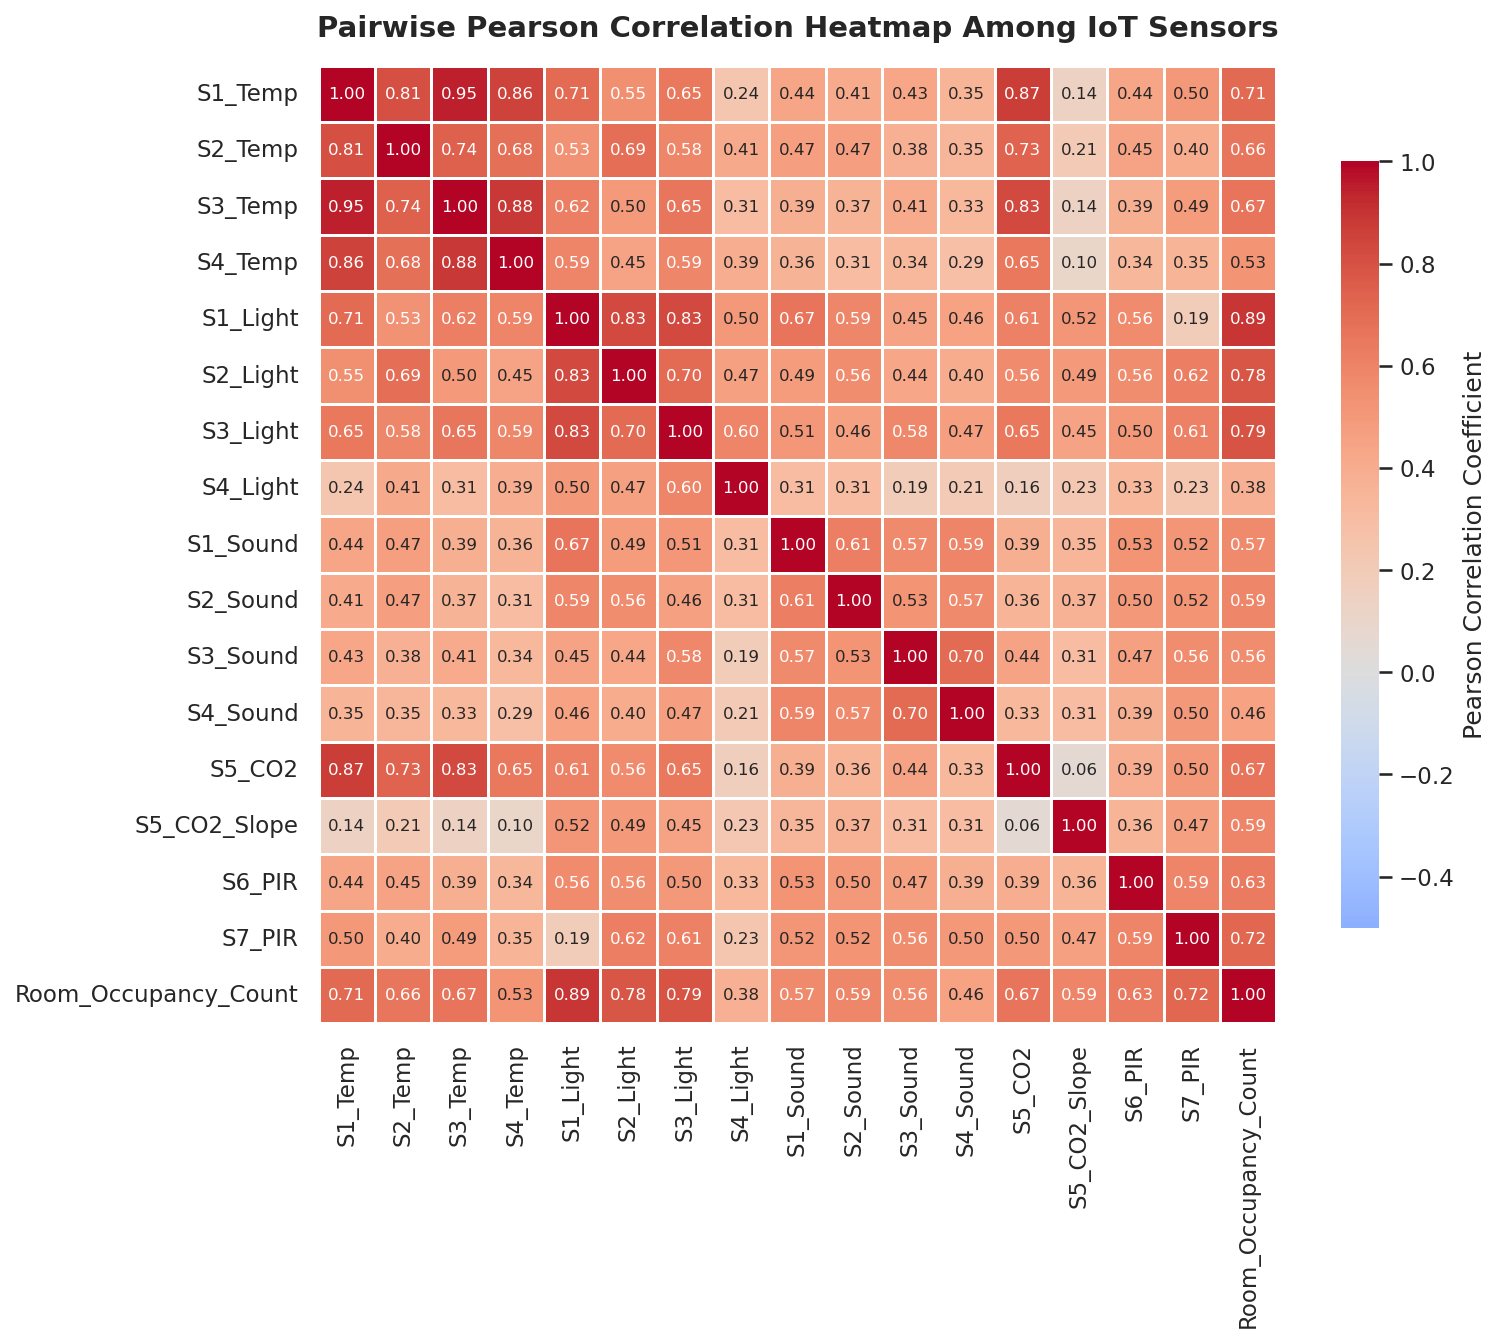

In [30]:
# Figure 6: Pairwise Pearson Correlation Heatmap
fig, ax = plt.subplots(figsize=(11, 9))
numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-0.5,
    vmax=1.0,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Pearson Correlation Coefficient", "shrink": 0.8},
    annot_kws={"size": 8}
)
ax.set_title("Pairwise Pearson Correlation Heatmap Among IoT Sensors", fontsize=14, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()

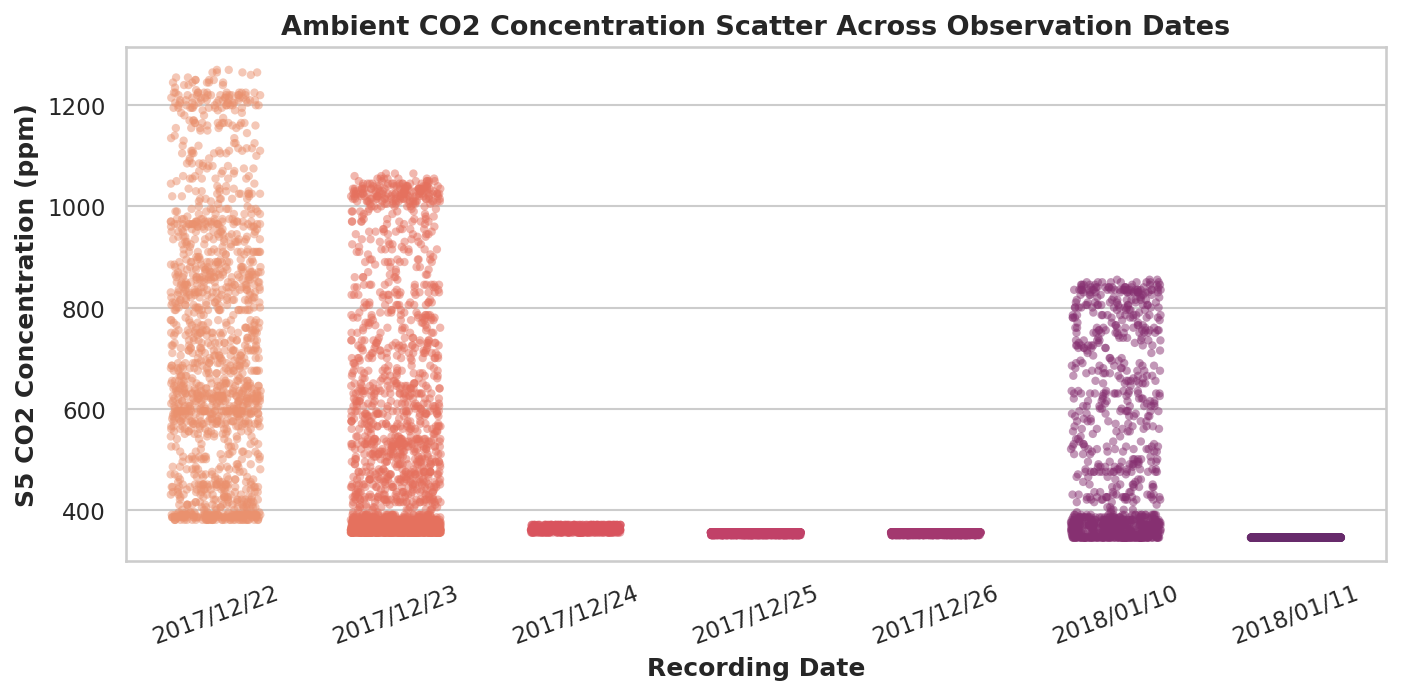

In [31]:
# Figure 7: Scatter Plot of CO2 Concentration Across Dates
fig, ax = plt.subplots(figsize=(9.5, 4.8))
scatter_df = df.dropna(subset=["S5_CO2", "Date"]).copy()
sns.stripplot(
    data=scatter_df,
    x="Date",
    y="S5_CO2",
    jitter=0.25,
    size=4,
    alpha=0.5,
    palette="flare",
    hue="Date",
    legend=False,
    ax=ax
)
ax.set_title("Ambient CO2 Concentration Scatter Across Observation Dates", fontsize=13, fontweight="bold")
ax.set_xlabel("Recording Date", fontweight="bold")
ax.set_ylabel("S5 CO2 Concentration (ppm)", fontweight="bold")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 11. Engineering Insights & Analytical Conclusion

1. **Light & PIR Motion as Primary Predictors:** The correlation heatmap confirms that ambient illuminance (`S1_Light` $r = 0.89$, `S3_Light` $r = 0.79$) and motion sensors (`S7_PIR` $r = 0.72$) exhibit the highest linear association with human occupancy.
2. **CO2 Accumulation Dynamics:** As room occupancy increases from 0 to 3 persons, mean CO2 levels rise markedly, providing strong discriminative signals for machine learning occupancy estimation.
3. **Data Quality & Imputation:** Missing value analysis revealed 57,671 null points across 10,129 rows. Imputation benchmarking underscores the importance of choosing domain-specific filling strategies (e.g. median/zero vs mean) to prevent bias in energy-management sensor models.
